# Tests on the TrustRegionRadius.jl package

📖 **Documentation:** <https://jeremyrieussec.github.io/TrustRegionRadius.jl/dev/>

To use the package TrustRegionRadius in development mode, uncomment the following line and run it once
```julia
Pkg.develop(path="C:/Users/jerem/OneDrive/Desktop/GitHub/TrustRegionRadius.jl") 
```
Packages used in this notebook:
```julia 
Pkg.add(["ADNLPModels", "CUTEst", "LinearAlgebra",  "Plots", "StatsPlots", "TOML", "Dates", "Printf", "NLPModels", "JLD2"])
``` 

In [1]:
using Pkg
Pkg.activate(".")

include("initialisation.jl")

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark`


| Experiment | Julia command | Description |
|------------|---------------|-------------|
| **1** | `comparison()` | Comparison of different trust-region radius update rules. |
| **2** | `trajectories()` | Comparison of trajectories for the gradient norm, trust-region radius, and trust-region ratio for different trust-region radius update rules. |
| **3** | `zeta_sweep()` | Comparison of different $\zeta$ values for R-DFO. |
| **4** | `mu_sweep()` | Comparison of different $\mu_{\max}$ values for R-Grad. |
| **5** | `inactivity()` | Direct measurement of trust-region inactivity. |
| **6** | `interaction()` | Interaction between the trust-region radius update mechanism and the model Hessian. |
| **7** | `CVRate()` | Comparison of the observed local convergence order. |
| **8** | `single_problem_experiment(::String)` | Runs all mechanisms on a single problem with detailed per-iteration diagnostics. ⚠️ **source file missing** — see note below. |
| **9** | `second_order()` | First- versus second-order anchoring: $\tau = \max\{\|g\|, -\lambda_{\min}\}$ against $\|g\|$ at a saddle. |
| **11** | `bhhh_study()` | Outer-product Hessians: where BHHH is justified and where it is not. |
| **12** | `sampling_examples()` | The three worked examples under every sampling rule. |

⚠️ **Two gaps in the suite.** The experiment filenames were shifted by one against their
contents (`exp2_trajectories.jl` defined `comparison()`, i.e. experiment 1, and so on down
the line). They have been renamed so each file matches what it defines — which leaves
**experiment 8 with no source at all**, since the file that carried its name held
experiment 7. `single_problem_experiment` is undefined until that file is written, and cell
11 below will fail. **Experiment 10** is absent as well: the suite jumps from 9 to 11.

In [2]:
# =============================================================================
# Central configuration — mirrors benchmark/config.jl.
#
# `initialisation.jl` already includes config.jl, so re-running this cell is only
# needed if you want to override something interactively. Re-running it with a
# DIFFERENT value will warn about redefining a constant and keep the old one;
# restart the kernel to change a `const`.
# =============================================================================

# Solver parameters — identical for every mechanism, deliberately.
# Per-rule tuning would measure tuning effort rather than algorithmic merit.
SOLVER_PARAMS   # tol = 1e-5, η = η1 = 0.1, η2 = 0.9, Δ0 = 1.0

# The same, with the second-order stopping test switched on. tol_H = -1 in
# SOLVER_PARAMS disables it and costs no curvature estimate; tol_H > 0 makes the
# run refuse to stop at a saddle and report :second_order when it certifies
# λ_min(B) ≥ -tol_H.
SECOND_ORDER_PARAMS

# The mechanisms. Note the keywords are ASCII (γ1, γ2, γ3, η1, η2, Δ0); the
# subscript spellings are accepted as aliases.
for (nm, f) in RULES
    println(rpad(nm, 20), f())
end
println()
println("τ-anchored twins (experiment 9):")
for (nm, f) in TAU_RULES
    println(rpad(nm, 22), asymptotic_regime(f()))
end

RDelta              RDelta(γ1 = 0.25, γ2 = 0.5, γ3 = 2.0, Δmin = 0.0, Δmax = Inf)
RStep               RStep(γ1 = 0.25, γ2 = 0.8, γ3 = 2.0, Δmin = 1.0e-14, Δmax = Inf, contract_on_step = true)
RDFO                RDFO(γ1 = 0.25, γ2 = 0.5, γ3 = 2.0, ζ = 100.0, Δmin = 0.0, Δmax = Inf)
RGrad               RGrad(γ1 = 0.25, γ2 = 0.5, γ3 = 2.0, μ = 1.0, μ0 = 1.0, half_test = true, Δmin = 0.0, Δmax = Inf)
RGradCapped         RGradCapped(γ1 = 0.25, γ2 = 0.5, γ3 = 2.0, μ = 1.0, μ0 = 1.0, μ_max = 128.0, half_test = true, Δmin = 0.0, Δmax = Inf)
RAdaptiveStep       RAdaptiveStep(γ1 = 0.0625, γ2 = 0.5, γ3 = 4.0, λ1 = 5.0, λ2 = 5.0, Δmin = 1.0e-14, Δmax = Inf)
RAdaptiveGrad       RAdaptiveGrad(μ = 1.0, μ0 = 1.0, γ1 = 0.0625, γ2 = 0.5, γ3 = 4.0, λ1 = 5.0, λ2 = 5.0, Δmin = 0.0, Δmax = Inf)

τ-anchored twins (experiment 9):
RGradTau              vanishing
RGradCappedTau        vanishing
RDFOTau               vanishing
RAdaptiveGradTau      vanishing


In [3]:
comparison() 

┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-54-07_comparison
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-54-07_comparison\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188
┌ Info: CUTEst: 3 problems selected
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\harness.jl:74
┌ Info: Experiment 1: 3 problems × 7 mechanisms
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\experiments\exp1_comparison.jl:21


problem                     RDelta         RStep          RDFO         RGrad   RGradCapped RAdaptiveStep RAdaptiveGrad
----------------------------------------------------------------------------------------------------------------------
AKIVA                            8            16             8             8             8            11             8
BEALE                            8             7             7            17            17             7            11
BOXBODLS                        32            47            30            44            44            41            28


┌ Info: table → tables\exp1_success_rate.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: figure → figures\exp1_perf_profile_iter.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp1_perf_profile_fevals.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp1_data_profile.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: Wrote summary → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-54-07_comparison\experiment_summary.md
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:414


"c:\\Users\\jerem\\OneDrive\\Desktop\\GitHub\\TrustRegionRadius.jl\\benchmark\\results\\exp_2026-08-05_11-54-07_comparison\\experiment_summary.md"

In [4]:
trajectories()

┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-55-23_trajectories
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-55-23_trajectories\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188
┌ Info: CUTEst: 3 problems selected
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\harness.jl:74


problem                     RDelta         RStep          RDFO         RGrad   RGradCapped RAdaptiveStep RAdaptiveGrad
----------------------------------------------------------------------------------------------------------------------
ROSENBR                         31            43            36            36            36            44            40
BEALE                            8             7             7            17            17             7            11
HIMMELBLAU                       7             7             8            10            10            10            13


┌ Info: figure → figures\exp2_delta_traj_ROSENBR.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp2_grad_traj_ROSENBR.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp2_ratio_traj_ROSENBR.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp2_delta_traj_BEALE.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp2_grad_traj_BEALE.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp2_ratio_traj_BEALE.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp2_delta_traj_HIMMELBLAU.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\b

"c:\\Users\\jerem\\OneDrive\\Desktop\\GitHub\\TrustRegionRadius.jl\\benchmark\\results\\exp_2026-08-05_11-55-23_trajectories\\experiment_summary.md"

In [5]:
zeta_sweep()

┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-02_zeta_sweep
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-02_zeta_sweep\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188
┌ Info: CUTEst: 3 problems selected
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\harness.jl:74


problem                  zeta=0.01      zeta=0.1      zeta=0.5        zeta=1        zeta=2       zeta=10      zeta=100
----------------------------------------------------------------------------------------------------------------------
AKIVA                            8             8             8             8             8             8             8
BEALE                         2835             7             7             7             7             7             7
BOXBODLS                        44            29            30            30            30            30            30


┌ Info: table → tables\exp3_zeta_summary.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: figure → figures\exp3_perf_profile_zeta.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp3_solverate_vs_zeta.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: table → tables\exp3_zeta_activity.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: Wrote summary → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-02_zeta_sweep\experiment_summary.md
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:414


"c:\\Users\\jerem\\OneDrive\\Desktop\\GitHub\\TrustRegionRadius.jl\\benchmark\\results\\exp_2026-08-05_11-56-02_zeta_sweep\\experiment_summary.md"

In [6]:
mu_sweep()

┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-12_mu_sweep
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-12_mu_sweep\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188
┌ Info: CUTEst: 3 problems selected
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\harness.jl:74


problem                mu_max=0.01   mu_max=0.05    mu_max=0.1    mu_max=0.5      mu_max=1      mu_max=2      mu_max=8    mu_max=128
------------------------------------------------------------------------------------------------------------------------------------
AKIVA                          426            85            12             9             8             8             8             8
BEALE                         3082           566           208            38            17            15            16            18
BOXBODLS                       345           202             3             4           128             5             6             8


┌ Info: table → tables\exp4_mu_summary.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: figure → figures\exp4_perf_profile_mu.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp4_solverate_vs_mu.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: table → tables\exp4_cauchy_diagnostic.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: Wrote summary → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-12_mu_sweep\experiment_summary.md
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:414


"c:\\Users\\jerem\\OneDrive\\Desktop\\GitHub\\TrustRegionRadius.jl\\benchmark\\results\\exp_2026-08-05_11-56-12_mu_sweep\\experiment_summary.md"

In [7]:
inactivity()

┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-27_inactivity
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-27_inactivity\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188


problem                     RDelta         RStep     RDFO(z=1)  RDFO(z=0.01)         RGrad   RGradCapped
--------------------------------------------------------------------------------------------------------


┌ Info: CUTEst: 3 problems selected
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\harness.jl:74


AKIVA                            8            16             8             8             8            85
BEALE                            8            12             7          2835            17           566
BOXBODLS                        32            47            30            44            44           202


┌ Info: table → tables\exp5_inactivity_summary.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: figure → figures\exp5_tail_active.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp5_active_trajectory_AKIVA.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: Wrote summary → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-27_inactivity\experiment_summary.md
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:414


"c:\\Users\\jerem\\OneDrive\\Desktop\\GitHub\\TrustRegionRadius.jl\\benchmark\\results\\exp_2026-08-05_11-56-27_inactivity\\experiment_summary.md"

In [8]:
interaction()

┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-40_interaction
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-40_interaction\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188
┌ Info: CUTEst: 3 problems selected
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\harness.jl:74


problem               RDelta/exact   RStep/exact    RDFO/exact   RGrad/exact  RDelta/LBFGS   RStep/LBFGS    RDFO/LBFGS   RGrad/LBFGS    RDelta/SR1     RStep/SR1      RDFO/SR1     RGrad/SR1      RDelta/I       RStep/I        RDFO/I       RGrad/I
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
AKIVA                            8            16             8             8            33            24            30            26            15            34            12            28          4148          3986          6838          6437
BEALE                            8            12             7            17            15            18            15            20            37            32            19            28           385           414           622           545
BOXBODLS            

┌ Info: table → tables\exp6_interaction_grid.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: figure → figures\exp6_interaction_heatmap.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: table → tables\exp6_additivity.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: Wrote summary → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-56-40_interaction\experiment_summary.md
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:414


"c:\\Users\\jerem\\OneDrive\\Desktop\\GitHub\\TrustRegionRadius.jl\\benchmark\\results\\exp_2026-08-05_11-56-40_interaction\\experiment_summary.md"

In [9]:
CVRate()

problem                     RDelta         RStep          RDFO         RGrad   RGradCapped RAdaptiveStep RAdaptiveGrad
----------------------------------------------------------------------------------------------------------------------


┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-57-14_convergence_rate
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-57-14_convergence_rate\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188
┌ Info: CUTEst: 3 problems selected
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\harness.jl:74


AKIVA                            9            17             9             9             9            12             9
BEALE                           10             9             9            18            18             9            12
BOXBODLS                        33            48            31            45            45            42            29


┌ Info: table → tables\exp7_conv_order_summary.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: table → tables\exp7_order_by_rule.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: figure → figures\exp7_conv_order_boxplot.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp7_conv_order_scatter.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: Wrote summary → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-57-14_convergence_rate\experiment_summary.md
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:414


"c:\\Users\\jerem\\OneDrive\\Desktop\\GitHub\\TrustRegionRadius.jl\\benchmark\\results\\exp_2026-08-05_11-57-14_convergence_rate\\experiment_summary.md"

---
## Experiment 9 — first- versus second-order anchoring

Every mechanism controls the radius against a *criticality measure*. The first-order
measure $\|g_k\|$ vanishes at **every** critical point — minimisers, saddles and maxima
alike. The second-order measure

$$\tau_k = \max\bigl\{\|g_k\|,\; -\lambda_{\min}(B_k)\bigr\}$$

vanishes only where the model is genuinely second-order critical.

The test problem is $f = x^4/4 - x^2/2 + y^2/2$, started at $(0, 0.7)$. The $x$-axis is
invariant under the gradient flow, so the trajectory runs **exactly** into the saddle at
the origin — the failure needs no tuning to provoke.

Four claims, and the last two are the ones worth internalising:

1. **The anchor collapses.** `RGrad` sets $\Delta = \mu\|g\| \to 0$ and halts; `RDFO`
   contracts geometrically for ever. Both then report `:first_order` — correctly by their
   own test. It is the test that is wrong.
2. **The measure gap.** $\tau_k/\|g_k\|$ is 1 on the convex part and unbounded at the
   saddle.
3. **The subsolver is half the story.** $\tau$ keeps the radius positive; it does not make
   the step go anywhere. Only $\tau$ *and* `EigenPoint` together reach a minimiser.
4. **The model is the other half.** Over `LBFGSModel`, $\lambda_{\min} > 0$ always, so
   $\tau \equiv \|g\|$ and the whole apparatus is an expensive no-op — which will still
   report `:second_order` at a saddle. The status certifies the *model*, not the function.

In [10]:
second_order()

┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-57-23_second_order
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-57-23_second_order\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188
┌ Info: table → tables\exp9_grid.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233


configuration                      status   iters       limit        f(x*)        Δ_end
----------------------------------------------------------------------------------------
RGrad  ‖g‖  Steihaug          first_order       1      saddle     0.000000    0.000e+00
RGrad  ‖g‖  EigenPoint        first_order       1      saddle     0.000000    0.000e+00
RGrad  τ    Steihaug              stalled       2      saddle     0.000000    2.000e+00
RGrad  τ    EigenPoint       second_order       3   minimiser    -0.250000    0.000e+00
RDFO   ‖g‖  Steihaug          first_order       1      saddle     0.000000    5.000e-01
RDFO   ‖g‖  EigenPoint        first_order       3   minimiser    -0.250000    5.000e-01
RDFO   τ    Steihaug              stalled       2      saddle     0.000000    2.000e+00
RDFO   τ    EigenPoint       second_order       2   minimiser    -0.250000    1.000e+00

The saddle has f = 0; each minimiser has f = −0.25.
A run that reports :first_order at the saddle has not failed by it

┌ Warning: τ ≡ ‖g‖: this model is positive (semi)definite by construction, so λ_min(B) ≥ 0 always and the second-order machinery is a no-op. A :second_order status from this run certifies nothing about ∇²f. Use ExactHessian or SR1Model when the second-order question is the question.
│   model = LBFGSModel
└ @ TrustRegionRadius C:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\src\Trust-region\common.jl:208
┌ Info: table → tables\exp9_blind.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: figure → figures\exp9_radius.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp9_measure_gap.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\

problem                      RGrad      RGradTau   RGradCappedRGradCappedTau          RDFO       RDFOTau RAdaptiveGradRAdaptiveGradT
------------------------------------------------------------------------------------------------------------------------------------


┌ Info: figure → figures\exp9_gap_ratio.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218
┌ Info: figure → figures\exp9_curvature.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218


saddle_quartic             stalled             3       stalled             3             2             2       stalled             2
monkey_saddle                   20       stalled      max_iter       stalled      max_iter      max_iter       stalled       stalled


┌ Info: table → tables\exp9_paired.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: Wrote summary → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-57-23_second_order\experiment_summary.md
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:414


### Reading `exp9_paired.txt`

The paired sweep runs each $\|g\|$-anchored rule beside its $\tau$-twin through the shared
harness, so the runs are archived and resumable like every other experiment.

Read the **certified `:second_order`** column against **solved**. A configuration that
solves every problem while certifying none has been running a first-order method under a
second-order name — which is exactly what a $\tau$-rule over a positive semidefinite model
does.

Two things had to change in the harness before this experiment could report anything at
all, and both are worth knowing about if you have archived runs from before:

- **`solved` now counts `:second_order`.** It tested `=== :first_order`, so a $\tau$-run
  that certified a minimiser was recorded as a *failure*: the columns doing best would
  have shown zero reliability.
- **`RunRecord` now carries `tau_traj` and `lambda_traj`.** They were dropped, so claim 2
  could not be plotted from an archived run.

Archives written before those fields existed reload fine — the missing keys default rather
than raising — but their `tau_traj` will be empty.

status        : second_order
solution      : [-1.0, 0.0]   (saddle is [0,0])
max τ/‖g‖     : 1.429
min λ_min(B)  : -1.0


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 4 for log10 based yscale
└ @ Plots C:\Users\jerem\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 4 for log10 based yscale
└ @ Plots C:\Users\jerem\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\jerem\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warnin

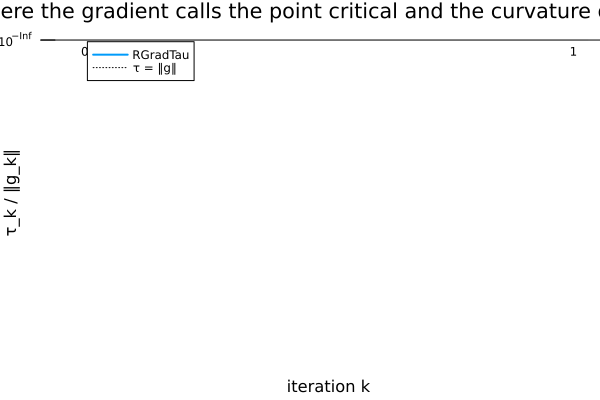

In [11]:
# The measure gap on a single run, without the archive layer.
st = tr_solve(ADNLPModel(v -> v[1]^4/4 - v[1]^2/2 + v[2]^2/2, [0.0, 0.7]);
              rule      = RGradTau(μ = 1.0),
              model     = ExactHessian(),              # must report λ_min < 0
              subsolver = EigenPoint(SteihaugCG()),    # must exploit it
              params    = TRParams(tol = 1e-8, tol_H = 1e-6), trace = true)

ss = st.solver_specific
gap = ss[:tau_trajectory] ./ max.(ss[:grad_trajectory], 1e-300)

println("status        : ", st.status)
println("solution      : ", round.(st.solution, digits = 6), "   (saddle is [0,0])")
println("max τ/‖g‖     : ", round(maximum(gap), digits = 3))
println("min λ_min(B)  : ", round(minimum(ss[:lambda_min_trajectory]), digits = 4))

plot(0:length(gap)-1, gap; yscale = :log10, lw = 2, legend = :topleft,
     xlabel = "iteration k", ylabel = "τ_k / ‖g_k‖", label = "RGradTau",
     title = "where the gradient calls the point critical and the curvature does not")
hline!([1.0]; ls = :dot, c = :black, label = "τ = ‖g‖")

In [12]:
# ⚠️ Experiment 8 has no source file (see the note under the table above), so
# `single_problem_experiment` is undefined. The CUTEst setup is kept so the cell
# is ready the moment that file exists.
try
    finalize(my_nlp)
catch e
    @warn "No need to finalize: $e"
end

my_nlp = CUTEstModel("ROSENBR")

println("#"^70)
println("Tracing problem: $(my_nlp.meta.name), with : \n  + $(my_nlp.meta.nvar) variables \n  + x0 = $(my_nlp.meta.x0).")
println("#"^70)

if isdefined(Main, :single_problem_experiment)
    single_problem_experiment("ROSENBR")
else
    @warn "single_problem_experiment is not defined: experiments/exp8_single_problem.jl is missing."
end

┌ Warning: No need to finalize: UndefVarError(:my_nlp, Main)
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:7


######################################################################
Tracing problem: ROSENBR, with : 
  + 2 variables 
  + x0 = [-1.2, 1.0].
######################################################################


┌ Warning: single_problem_experiment is not defined: experiments/exp8_single_problem.jl is missing.
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:19


---
## Experiments 11 and 12 — the sampled problem classes

These exercise the fourth axis. Both were adapted to the class split:

- `SampledNLP` → **`FiniteSumNLP`**, since every example here is a finite sum. The
  expectation branch is `ExpectationNLP`, a different type with a different solver.
- `LikelihoodNLP` → **`FullBatchNLP`**, the deterministic all-terms view. The old name
  survives as an alias; the new one says what it is.
- **`N_max` dropped from every sampling rule.** On a finite sum the cap is $M$, imposed by
  the problem, and a rule carrying a user `N_max` is now rejected at oracle construction —
  there it is either redundant ($\geq M$) or a deliberate sub-population budget ($< M$),
  and those are different intentions. Pass `budget` to the oracle for the second.

`BHHHModel` now requires a `LikelihoodProblem` and `GaussNewtonModel` an `NLSProblem`,
checked at solver construction. That check prevents a silent failure: applied to the wrong
problem BHHH still produces a positive semidefinite matrix and the run still converges,
and nothing in $\rho$, $\|g\|$ or the radius trace reveals that the model approximates
nothing in particular.

In [ ]:
bhhh_study()

┌ Info: Experiment archive → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-57-51_bhhh
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:129
┌ Info: Wrote config → c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\results\exp_2026-08-05_11-57-51_bhhh\experiment_config.toml
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:188


Relative error ‖B − ∇²f‖/‖∇²f‖ on logistic regression.

   K         M        at β*          ×√M    at β*+1.5    ‖B−W‖/‖∇²f‖
----------------------------------------------------------------------
   2       500      0.12212        2.731      1.17759        0.01142
   2      2000      0.04255        1.903      1.44727        0.00146
   2      8000      0.01464        1.310      1.57854        0.00025
   2     32000      0.00470        0.841      1.54433        0.00001
   2    128000      0.00768        2.749      1.53350        0.00002

   5       500      0.13149        2.940      1.85098        0.00144
   5      2000      0.07311        3.270      2.49045        0.00092
   5      8000      0.03800        3.399      2.36334        0.00003
   5     32000      0.01790        3.203      2.31435        0.00007
   5    128000      0.01710        6.117      2.29198        0.00005

  10       500      0.29054        6.497      3.61487        0.01451
  10      2000      0.12003        5.368   

┌ Info: table → tables\exp11_identity.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233
┌ Info: figure → figures\exp11_identity.pdf
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:218


model          rule           status   iters          ‖g‖       ‖β−β*‖
----------------------------------------------------------------------

ExactHessian   RDelta    first_order       7    3.615e-11       0.2019
ExactHessian   RStep     first_order       7    3.615e-11       0.2019
ExactHessian   RDFO         max_iter     500    1.324e-06       0.2018
ExactHessian   RGrad     first_order       9    7.051e-10       0.2019

BHHH           RDelta    first_order      10    2.829e-08       0.2019
BHHH           RStep     first_order      10    2.829e-08       0.2019
BHHH           RDFO         max_iter     500    1.324e-06       0.2018
BHHH           RGrad     first_order      21    3.199e-08       0.2019

BHHH-2         RDelta    first_order      14    9.056e-08       0.2019
BHHH-2         RStep     first_order      14    9.056e-08       0.2019
BHHH-2         RDFO         max_iter     500    1.324e-06       0.2018
BHHH-2         RGrad     first_order      24    7.852e-08       0.2019

SR

┌ Info: table → tables\exp11_mechanisms.txt
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark\archive.jl:233


In [ ]:
sampling_examples()